# FlashEats: Class 5 Investigation (solved)

## Client escalation

> **"Late deliveries are increasing and customers say our ETA is unreliable. Figure out what is happening before we invest in an AI delay-prediction system."**

Today is not a syntax lesson. Your job is to use SQL, CSV, JSON and APIs like an FDE:

**define the question → retrieve evidence → validate completeness → reconcile sources → state what you know and what you still cannot know**

### Rules
- Do not train an ML model.
- State your definition of **late** before calculating it.
- Preserve raw API responses.
- Do not silently drop failures.
- If another team gets a different answer, investigate the definition and data grain first.

> **How to run:** the FlashEats classroom pack is the instructor's material and is not in this repo. Put it in `Code/` at the repo root (so `Code/database/flasheats.db` exists), install `pandas requests flask matplotlib`, then run top to bottom.

In [1]:
# 0. IMPORTS
import os, sys, json, time, sqlite3, subprocess
from pathlib import Path

import pandas as pd
import requests
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

print("Environment ready.")

Environment ready.


In [2]:
# 1. LOAD THE CLASSROOM PACK
# Local run: look in the current folder, then in the repo's Code/ folder.

def find_pack_root():
    for candidate in [Path.cwd(), Path.cwd() / "Code", Path.cwd().parent / "Code"]:
        if (candidate / "database" / "flasheats.db").exists():
            return candidate
    raise FileNotFoundError("FlashEats pack not found. Put it in Code/ at the repo root.")

BASE = find_pack_root()
print("BASE found:", BASE.exists())

BASE found: True


## 2. Source map first

Before analysis, predict where you would look for:

| Information | Likely source | Why? |
|---|---|---|
| Promised delivery time | `orders.promised_eta` (SQLite) | The promise the customer saw at checkout. The dispatch API also has `current_delivery_eta`, an updated ETA |
| Actual delivery time | `orders.actual_delivery_at` (SQLite) | The order system of record. `driver_events.json` also has a `delivered` event |
| Driver assignment | Dispatch API (`assigned_at`, `reassigned_at`) | Dispatch owns assignment. `driver_events.json` has an `assigned` event too |
| Customer complaint | `support_tickets.csv` | What the customer said, in their words |
| Restaurant status | `restaurant_status.csv` | Status updates from the restaurant (some restaurants update by hand) |
| Driver movement/events | `driver_events.json` | GPS pings, pickup and delivery events per driver |

**Discuss:** Which source is authoritative for each fact, and which is only contextual?

- **Authoritative:** the orders table for created, promised and delivered times (it defines "late"); dispatch for who was assigned and when.
- **Contextual:** support tickets (perception, not what happened), restaurant status (manual updates), GPS pings (sparse, see Challenge 5).

In [3]:
# 3. BASIC SYNTAX: READ EVERY SOURCE

# SQLite
db_path = BASE / "database" / "flasheats.db"
con = sqlite3.connect(db_path)

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    con
)
display(tables)

sample_orders = pd.read_sql("SELECT * FROM orders LIMIT 5;", con)
display(sample_orders)

# CSV
tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")
display(tickets.head())

# Nested JSON
with open(BASE / "data" / "driver_events.json", "r") as f:
    driver_events = json.load(f)

print("Driver objects:", len(driver_events))
display(driver_events[:1])

,name
0,customers
1,drivers
2,orders
3,restaurants


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Driver objects: 120


[{'driver_id': 'D001',
  'events': [{'order_id': 'O00162',
    'type': 'assigned',
    'timestamp': '2026-08-26T17:53:25.977803'},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:10:59.372420',
    'lat': 12.826339,
    'lon': 77.448282},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:28:32.767037',
    'lat': 12.876013,
    'lon': 77.477707},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T18:46:06.161653',
    'lat': 12.925686,
    'lon': 77.507133},
   {'order_id': 'O00162',
    'type': 'gps_ping',
    'timestamp': '2026-08-26T19:03:39.556270',
    'lat': 12.97536,
    'lon': 77.536558},
   {'order_id': 'O00162',
    'type': 'picked_up',
    'timestamp': '2026-08-26T18:27:32.131791'},
   {'order_id': 'O00162',
    'type': 'delivered',
    'timestamp': '2026-08-26T19:21:12.950887'},
   {'order_id': 'O00180',
    'type': 'assigned',
    'timestamp': '2026-08-08T18:05:08.439625'},
   {'o

# Challenge 1: How large is the late-delivery problem?

Before coding, decide:

- **Late means:** `actual_delivery_at` is after the original `promised_eta` (delay greater than 0 minutes). A grace period is a business choice; we show 10 minutes beside it.
- **Denominator:** valid delivered orders: status delivered, with both a promised ETA and an actual delivery time.
- **Cancelled orders:** exclude. They have no delivery that could be late.
- **Missing actual delivery timestamp:** exclude from the rate, but **count and report** them, and show how far they could move the number.
- **Row grain:** one row should be one order, so check `order_id` uniqueness and keep one row per order.

### Required analysis
1. valid delivered orders,
2. late count and percentage,
3. median lateness among late orders,
4. worst delayed orders,
5. any data-quality issue that changes the metric.

In [4]:
# Grain first: is one row one order?
orders = pd.read_sql("SELECT * FROM orders;", con)
print("Rows:", len(orders), "| unique order_id:", orders["order_id"].nunique())

dupes = orders[orders["order_id"].duplicated(keep=False)].sort_values("order_id")
display(dupes[["order_id", "final_status", "actual_delivery_at", "traffic_bucket", "weather_bucket"]])

Rows: 1603 | unique order_id: 1600


,order_id,final_status,actual_delivery_at,traffic_bucket,weather_bucket
119,O00120,delivered,2026-08-13T19:34:08.431508,severe,clear
1600,O00120,delivered,2026-08-13T19:34:08.431508,medium,clear
722,O00723,delivered,2026-08-05T22:04:30.928322,medium,clear
1601,O00723,delivered,2026-08-05T22:04:30.928322,high,clear
1301,O01302,delivered,2026-08-26T22:20:27.428561,medium,clear
1602,O01302,delivered,2026-08-26T22:20:27.428561,high,clear


In [5]:
# Status labels: are they consistent?
print(orders["final_status"].value_counts(dropna=False))

final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64


In [6]:
# One row per order. The duplicate copies agree on every delivery field, so which copy
# we keep does not change the late rate (it would matter for a traffic analysis).
order_analysis = orders.drop_duplicates("order_id", keep="first").copy()

for c in ["created_at", "promised_eta", "pickup_at", "actual_delivery_at"]:
    order_analysis[c] = pd.to_datetime(order_analysis[c], format="mixed", errors="coerce")

# "Delivered" vs "delivered" is only a difference in case, so it is safe to normalise
order_analysis["status"] = order_analysis["final_status"].str.strip().str.lower()

delivered = order_analysis[order_analysis["status"] == "delivered"]
missing_delivery_time = delivered["actual_delivery_at"].isna()

valid = delivered[delivered["actual_delivery_at"].notna() & delivered["promised_eta"].notna()].copy()
valid["delay_min"] = (valid["actual_delivery_at"] - valid["promised_eta"]).dt.total_seconds() / 60
late = valid[valid["delay_min"] > 0]

summary = pd.Series({
    "unique orders": len(order_analysis),
    "cancelled": int((order_analysis["status"] == "cancelled").sum()),
    "delivered": len(delivered),
    "delivered but no actual delivery time": int(missing_delivery_time.sum()),
    "valid delivered orders (denominator)": len(valid),
    "late (delay > 0 min)": len(late),
    "late %": round(100 * len(late) / len(valid), 1),
    "median lateness among late orders (min)": round(late["delay_min"].median(), 1),
    "late % with a 10 min grace period": round(100 * (valid["delay_min"] > 10).mean(), 1),
})
summary.to_frame("value")

,value
unique orders,1600.0
cancelled,68.0
delivered,1532.0
delivered but no actual delivery time,37.0
valid delivered orders (denominator),1495.0
late (delay > 0 min),843.0
late %,56.4
median lateness among late orders (min),8.0
late % with a 10 min grace period,23.3


In [7]:
# Same answer in SQL, as a cross-check (SQLite has no median, so that part stays in pandas)
pd.read_sql("""
SELECT COUNT(*) AS valid_delivered,
       SUM(CASE WHEN julianday(actual_delivery_at) > julianday(promised_eta) THEN 1 ELSE 0 END) AS late,
       ROUND(100.0 * SUM(CASE WHEN julianday(actual_delivery_at) > julianday(promised_eta) THEN 1 ELSE 0 END)
             / COUNT(*), 1) AS late_pct
FROM orders
WHERE rowid IN (SELECT MIN(rowid) FROM orders GROUP BY order_id)   -- one row per order_id
  AND LOWER(TRIM(final_status)) = 'delivered'
  AND actual_delivery_at IS NOT NULL
  AND promised_eta IS NOT NULL;
""", con)

,valid_delivered,late,late_pct
0,1495,843,56.4


In [8]:
# Worst delayed orders, with a chronology check beside each one
valid["eta_before_created"] = valid["promised_eta"] < valid["created_at"]
valid["delivered_before_pickup"] = valid["actual_delivery_at"] < valid["pickup_at"]

worst = valid.sort_values("delay_min", ascending=False).head(8)
display(worst.assign(delay_min=worst["delay_min"].round(1))[
    ["order_id", "created_at", "promised_eta", "actual_delivery_at", "delay_min",
     "traffic_bucket", "weather_bucket", "eta_before_created"]])

,order_id,created_at,promised_eta,actual_delivery_at,delay_min,traffic_bucket,weather_bucket,eta_before_created
103,O00104,2026-08-09 22:19:00,2026-08-09 22:09:00.000000,2026-08-09 23:36:20.740161,87.3,medium,clear,True
101,O00102,2026-08-11 16:41:00,2026-08-11 16:31:00.000000,2026-08-11 17:57:17.661772,86.3,medium,clear,True
100,O00101,2026-08-24 20:59:00,2026-08-24 20:49:00.000000,2026-08-24 22:14:30.685278,85.5,low,rain,True
102,O00103,2026-08-22 20:11:00,2026-08-22 20:01:00.000000,2026-08-22 21:10:17.342305,69.3,high,clear,True
1080,O01081,2026-08-13 17:14:00,2026-08-13 18:15:46.613098,2026-08-13 19:06:02.677891,50.3,high,clear,False
472,O00473,2026-08-14 18:58:00,2026-08-14 20:17:48.000000,2026-08-14 21:04:00.769224,46.2,high,clear,False
1101,O01102,2026-08-12 18:25:00,2026-08-12 19:31:12.651822,2026-08-12 20:16:09.835907,45.0,medium,clear,False
193,O00194,2026-08-11 17:36:00,2026-08-11 19:01:48.000000,2026-08-11 19:40:08.111510,38.3,high,heavy_rain,False


In [9]:
# Data-quality issues that change (or could change) the metric
n_valid, n_late, n_missing = len(valid), len(late), int(missing_delivery_time.sum())
bad_chronology = valid["eta_before_created"] | valid["delivered_before_pickup"]
clean = valid[~bad_chronology]

pd.DataFrame([
    {"issue": "Delivered orders with no actual delivery time", "orders": n_missing,
     "effect on late %": f"between {100 * n_late / (n_valid + n_missing):.1f}% (none late) "
                         f"and {100 * (n_late + n_missing) / (n_valid + n_missing):.1f}% (all late)"},
    {"issue": "Promised ETA earlier than order creation", "orders": int(valid["eta_before_created"].sum()),
     "effect on late %": "they are the 4 largest 'delays'; they distort any worst-delay list or average"},
    {"issue": "Delivered before pickup", "orders": int(valid["delivered_before_pickup"].sum()),
     "effect on late %": "impossible order of events"},
    {"issue": "Late % without the 9 chronology violators", "orders": len(clean),
     "effect on late %": f"{100 * (clean['delay_min'] > 0).mean():.1f}%"},
])

,issue,orders,effect on late %
0,Delivered orders with no actual delivery time,37,between 55.0% (none late) and 57.4% (all late)
1,Promised ETA earlier than order creation,4,they are the 4 largest 'delays'; they distort any worst-delay list or average
2,Delivered before pickup,5,impossible order of events
3,Late % without the 9 chronology violators,1486,56.3%


**Challenge 1 answer.** Under the stated definition, **843 of 1,495 valid delivered orders (56.4%) were late**, and the median late order arrived **8.0 minutes** after the promise.

Things that change the number:
- **Grain:** 1,603 rows but 1,600 orders. Three orders appear twice (their copies disagree on `traffic_bucket`). Without deduplication you get 56.34%.
- **Labels:** 5 rows say `Delivered` with a capital D. An exact match on `"delivered"` would silently drop them.
- **37 delivered orders have no delivery time.** They are excluded and reported, not guessed: the true rate lies between **55.0% and 57.4%**.
- **4 orders have a promised ETA before they were created**, so the four "worst" delays (69 to 87 min) are data errors. The worst real delay is O01081, 50.3 min late.
- **Definition:** a 10 minute grace period drops the rate to 23.3%. The definition moves the number more than any data issue.

## Checkpoint

Compare your answer with another team.

If your counts differ, investigate:
- duplicate rows,
- cancelled orders,
- missing timestamps,
- late-delivery definition,
- row grain.

**Our reconciliation:** 56.34% means the duplicates were kept (844 of 1,498). 1,490 valid orders means `Delivered` was dropped by an exact, case-sensitive match. 52.7% means every order was used as the denominator, so cancelled and undated orders count as "on time".

# Challenge 2: Operations says: "Traffic is the problem."

Test that claim using at least three dimensions.

Possible dimensions:
- traffic,
- weather,
- distance,
- time of day,
- restaurant,
- driver.

### Required output
- 2 to 3 comparisons,
- one chart or compact table,
- one hypothesis supported by evidence,
- one alternative explanation you cannot rule out.

Separate **association** from **causation**.

In [10]:
# traffic_bucket has "HIGH" (3 rows) beside "high": a case difference, safe to normalise
valid["traffic"] = valid["traffic_bucket"].str.strip().str.lower()

def delay_by(column):
    return valid.groupby(column, observed=True)["delay_min"].agg(
        orders="count", median_delay="median", late_rate=lambda s: (s > 0).mean()).round(2)

traffic_order = ["low", "medium", "high", "severe"]
traffic_summary = delay_by("traffic").reindex(traffic_order)
weather_summary = delay_by("weather_bucket").reindex(["clear", "rain", "heavy_rain"])
display(traffic_summary, weather_summary)

,orders,median_delay,late_rate
traffic,,,
low,360,-0.09,0.49
medium,588,0.26,0.51
high,424,3.99,0.67
severe,123,4.26,0.66


,orders,median_delay,late_rate
weather_bucket,,,
clear,1192,0.78,0.53
rain,231,4.27,0.67
heavy_rain,72,6.63,0.74


In [11]:
# Distance: bins up to 50 km so no order silently falls out of the table
valid["distance_band"] = pd.cut(valid["distance_km_estimate"], bins=[0, 3, 6, 10, 20, 50])
distance_summary = delay_by("distance_band")
display(distance_summary)
print("Orders in the distance table:", distance_summary["orders"].sum(), "of", len(valid))
print("Orders with distance exactly 18.0 km:", int((valid["distance_km_estimate"] == 18.0).sum()))

,orders,median_delay,late_rate
distance_band,,,
"(0, 3]",26,2.46,0.62
"(3, 6]",71,-0.43,0.48
"(6, 10]",194,1.78,0.57
"(10, 20]",1201,1.53,0.57
"(20, 50]",3,26.32,1.00


Orders in the distance table: 1495 of 1495
Orders with distance exactly 18.0 km: 749


In [12]:
# Is the traffic effect just rain? Median delay by traffic within each weather group
display(pd.crosstab(valid["traffic"], valid["weather_bucket"], values=valid["delay_min"], aggfunc="median")
          .reindex(traffic_order).round(1))
display(pd.crosstab(valid["traffic"], valid["weather_bucket"]).reindex(traffic_order))

weather_bucket,clear,heavy_rain,rain
traffic,,,
low,-0.7,8.5,1.2
medium,-0.4,4.8,3.9
high,3.1,6.6,5.9
severe,2.9,12.7,11.0


weather_bucket,clear,heavy_rain,rain
traffic,,,
low,295,12,53
medium,470,36,82
high,332,20,72
severe,95,4,24


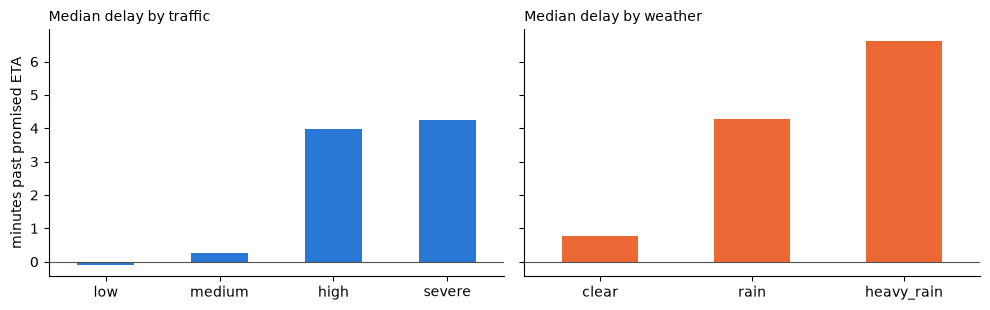

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
traffic_summary["median_delay"].plot(kind="bar", ax=axes[0], color="#2a78d6")
weather_summary["median_delay"].plot(kind="bar", ax=axes[1], color="#eb6834")
axes[0].set_title("Median delay by traffic", loc="left", fontsize=10)
axes[1].set_title("Median delay by weather", loc="left", fontsize=10)
axes[0].set_ylabel("minutes past promised ETA")
for ax in axes:
    ax.axhline(0, color="#52514e", lw=0.8)
    ax.tick_params(axis="x", rotation=0)
    ax.set_xlabel("")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Challenge 2 answer.**

| Comparison | What the data shows |
|---|---|
| Traffic | Median delay is about 0 for low and medium traffic, and about +4 min for high and severe. Late rate 49% to 51% vs 66% to 67% |
| Weather | Median delay +0.8 min in clear weather, +4.3 in rain, +6.6 in heavy rain |
| Distance | No clear pattern, **but the column cannot be trusted**: 749 of 1,495 orders (50%) sit at exactly 18.0 km, which looks like a default or cap |

- **Hypothesis supported by the evidence:** high or severe traffic **and** rain are each associated with later deliveries. The traffic pattern holds inside clear weather (-0.7, -0.4, +3.1, +2.9 min), so it is not just rain in disguise.
- **Alternative we cannot rule out:** the buckets are coarse labels that may stand in for something else, such as dinner-peak hours, particular restaurants that are slow to prepare, or driver supply. We have no timestamp for the driver reaching the restaurant, so we cannot tell a traffic delay from a kitchen delay.
- **So:** traffic is *associated* with delay. The data does not prove traffic *causes* it, and "traffic is the problem" ignores that about half of low-traffic orders are also late.

# Challenge 3: Customer Support disagrees

Use `support_tickets.csv`.

### Questions
1. What are customers actually complaining about?
2. Which complaint types are most common?
3. Are ticket IDs unique?
4. Does the customer story match the operational story?
5. What can tickets tell you that timestamps cannot?

### Required output
A short **system view vs customer view** comparison.

In [14]:
display(tickets.head())

print("Complaint categories:")
display(tickets["category"].value_counts())

print("Duplicate ticket IDs:")
print(tickets["ticket_id"].duplicated().sum())
display(tickets[tickets["ticket_id"].duplicated(keep=False)])
print("Tickets with no order_id:", tickets["order_id"].isna().sum())

,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


Complaint categories:


category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64

Duplicate ticket IDs:
1


,ticket_id,order_id,created_at,category,customer_message
12,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.
201,T00013,O00090,2026-08-20T18:14:00,late_delivery,My order is already past the promised time.


Tickets with no order_id: 3


In [15]:
# One row per ticket, and category labels that differ only in case, spaces or wording
# are shown side by side with their message rather than silently merged
ticket_analysis = tickets.drop_duplicates("ticket_id", keep="first").copy()
ticket_analysis["category_norm"] = ticket_analysis["category"].str.strip().str.lower().str.replace(" ", "_")
display(ticket_analysis.groupby(["category_norm", "category"]).size().rename("tickets").to_frame())

# Which message goes with which label? A label that disagrees with its own message is a semantic issue
display(ticket_analysis.groupby("category_norm")["customer_message"].unique().to_frame())

tickets
category_norm     category                  
driver_not_moving driver_not_moving       25
eta_changed       eta_changed             37
eta_issue         ETA issue                1
late_delivery     Late Delivery            1
                  late_delivery           37
                  late_delivery            1
ready_but_waiting ready_but_waiting       33
restaurant_delay  restaurant_delay        37
status_mismatch   status_mismatch         29

,customer_message
category_norm,
driver_not_moving,[The rider has not moved for 15 minutes.]
eta_changed,[The ETA keeps changing and the food is still not here.]
eta_issue,[The rider has not moved for 15 minutes.]
late_delivery,"[My order is already past the promised time., The rider has not moved for 15 minutes.]"
ready_but_waiting,[Restaurant says food is ready but no rider has picked it up.]
restaurant_delay,[Restaurant says they are still preparing my order.]
status_mismatch,[The app says picking up but the restaurant says it is ready.]


In [16]:
# System view for each ticketed order: was it really late?
tickets_with_delay = ticket_analysis.merge(
    valid[["order_id", "delay_min", "traffic", "weather_bucket"]], on="order_id", how="left")

customer_vs_system = tickets_with_delay.groupby("category_norm").agg(
    tickets=("ticket_id", "count"),
    matched_to_valid_order=("delay_min", "count"),
    median_delay_min=("delay_min", "median"),
    share_actually_late=("delay_min", lambda s: (s.dropna() > 0).mean()),
).sort_values("tickets", ascending=False).round(2)
customer_vs_system

,tickets,matched_to_valid_order,median_delay_min,share_actually_late
category_norm,,,,
late_delivery,39,38,14.78,0.87
restaurant_delay,37,37,10.45,0.76
eta_changed,37,35,7.65,0.80
ready_but_waiting,33,33,12.16,0.91
status_mismatch,29,28,12.68,0.93
driver_not_moving,25,25,10.37,0.68
eta_issue,1,1,5.40,1.00


In [17]:
# Does "already past the promised time" match the clock when the ticket was raised?
lt = tickets_with_delay[tickets_with_delay["category_norm"] == "late_delivery"].merge(
    order_analysis[["order_id", "promised_eta"]], on="order_id", how="inner")
lt["created_at"] = pd.to_datetime(lt["created_at"], format="mixed", errors="coerce")
print("late_delivery tickets with an order:", len(lt),
      "| raised before the promised ETA:", int((lt["created_at"] < lt["promised_eta"]).sum()))

print("Late orders with no ticket at all:",
      int((~late["order_id"].isin(ticket_analysis["order_id"])).sum()), "of", len(late))

late_delivery tickets with an order: 38 | raised before the promised ETA: 38
Late orders with no ticket at all: 680 of 843


**Challenge 3 answer.**

1. Customers complain about **lateness and uncertainty**: `late_delivery` (39 after cleaning), `eta_changed` (37), `restaurant_delay` (37), `ready_but_waiting` (33), `status_mismatch` (29), `driver_not_moving` (25).
2. Most common: `late_delivery`.
3. **No.** 202 rows, 201 unique IDs: `T00013` appears twice, so the counts above use one row per ticket. 3 tickets have no `order_id` and cannot be checked against any order.
4. **Broadly yes.** In the six main categories, ticketed orders were late 68% to 93% of the time, with median delays of 8 to 15 minutes, against 56% for all orders. But the label cannot always be trusted: `Late Delivery` (T00004) and `ETA issue` (T00006) carry the "rider has not moved" message, so normalising the spelling alone would file them under the wrong problem.

| | System view (timestamps) | Customer view (tickets) |
|---|---|---|
| What it measures | Minutes between promise and delivery | What the customer felt and saw in the app |
| Late orders | 843 | Only 163 of the 843 late orders (19%) have a ticket |
| Strength | Objective and complete for delivered orders | Tells *what kind* of problem: ETA changing, rider not moving, food ready but no rider |
| Weakness | Says nothing about why, or what the app showed | Labels are messy (`Late Delivery`, `ETA issue`), one ID is duplicated, and all 38 "already past the promised time" tickets were raised *before* the promised ETA |

5. **Tickets tell us the experience**: a frozen or changing ETA and a restaurant-vs-app status mismatch are invisible in delivery timestamps. But tickets are not the event log, so they never define "late".

# Challenge 4: Dispatch API: prove you retrieved everything

Your task:
1. start the API,
2. inspect one response,
3. retrieve **all** records,
4. handle pagination,
5. handle retryable failures,
6. save every successful raw page,
7. prove ingestion completeness.

A successful HTTP `200` on one page does **not** prove the job succeeded.

In [18]:
# Start the mock API
api_script = BASE / "api" / "mock_dispatch_api.py"

api_proc = subprocess.Popen(
    [sys.executable, str(api_script)],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)

time.sleep(2)
health = requests.get("http://127.0.0.1:8000/health", timeout=10)
print(health.status_code, health.json())

200 {'service': 'flasheats-dispatch-api', 'status': 'ok'}


In [19]:
# Basic API syntax
API_URL = "http://127.0.0.1:8000/dispatch/orders"

response = requests.get(
    API_URL,
    params={"page": 1, "page_size": 50},
    timeout=10
)

print("HTTP:", response.status_code)

if response.ok:
    payload = response.json()
    print("Keys:", payload.keys())
    print("Records on page:", len(payload["data"]))
    print("Has more:", payload["has_more"])
    print("Reported total:", payload["total_records"])

HTTP: 200
Keys: dict_keys(['data', 'has_more', 'page', 'page_size', 'total_records'])
Records on page: 50
Has more: True
Reported total: 1600


In [20]:
# Reliable paginated ingestion

RAW_DIR = BASE / "student_output" / "raw_dispatch"
RAW_DIR.mkdir(parents=True, exist_ok=True)
for old_page in RAW_DIR.glob("dispatch_page_*.json"):
    old_page.unlink()  # a rerun replaces the raw pages instead of mixing old and new

RETRYABLE = {429, 500, 502, 503, 504}

def get_page_with_retry(page, page_size, max_retries=4):
    """Retry only failures that can succeed on their own; fail loudly on anything else."""
    for attempt in range(1, max_retries + 1):
        response = requests.get(API_URL, params={"page": page, "page_size": page_size}, timeout=10)
        if response.status_code not in RETRYABLE:
            response.raise_for_status()   # e.g. a 404 is not retried: repeating it changes nothing
            return response.json()
        if attempt == max_retries:
            raise RuntimeError(f"Page {page}: gave up after {max_retries} attempts (HTTP {response.status_code})")
        # Honour the server's own wait hint when it gives one, otherwise back off 1s, 2s, 4s
        wait = response.json().get("retry_after_seconds", 2 ** (attempt - 1))
        print(f"  page {page}: HTTP {response.status_code}, attempt {attempt}/{max_retries}, retrying in {wait}s")
        time.sleep(wait)

def fetch_all_dispatch_orders(page_size=100):
    records, page, expected_total = [], 1, None
    while True:
        payload = get_page_with_retry(page, page_size)
        with open(RAW_DIR / f"dispatch_page_{page:03d}.json", "w") as f:
            json.dump(payload, f, indent=2)   # preserve the raw response before using it
        expected_total = payload["total_records"] if expected_total is None else expected_total
        records.extend(payload["data"])
        print(f"page {page}: {len(payload['data'])} records, cumulative {len(records)} of {expected_total}")
        if not payload["has_more"]:
            break
        page += 1
    if len(records) != expected_total:
        raise RuntimeError(f"Incomplete ingestion: got {len(records)}, expected {expected_total}")
    return records

dispatch_records = fetch_all_dispatch_orders()
print("Retrieved:", len(dispatch_records))

page 1: 100 records, cumulative 100 of 1600
page 2: 100 records, cumulative 200 of 1600
  page 3: HTTP 500, attempt 1/4, retrying in 1s


page 3: 100 records, cumulative 300 of 1600
page 4: 100 records, cumulative 400 of 1600
  page 5: HTTP 429, attempt 1/4, retrying in 1s


page 5: 100 records, cumulative 500 of 1600
page 6: 100 records, cumulative 600 of 1600
page 7: 100 records, cumulative 700 of 1600
page 8: 100 records, cumulative 800 of 1600
page 9: 100 records, cumulative 900 of 1600
page 10: 100 records, cumulative 1000 of 1600
page 11: 100 records, cumulative 1100 of 1600
page 12: 100 records, cumulative 1200 of 1600
page 13: 100 records, cumulative 1300 of 1600
page 14: 100 records, cumulative 1400 of 1600
page 15: 100 records, cumulative 1500 of 1600
page 16: 100 records, cumulative 1600 of 1600
Retrieved: 1600


In [21]:
# Completeness proof, beyond "every page returned 200"
dispatch = pd.DataFrame(dispatch_records)
saved_pages = sorted(RAW_DIR.glob("dispatch_page_*.json"))
records_in_raw = sum(len(json.loads(p.read_text())["data"]) for p in saved_pages)

pd.Series({
    "API reported total_records": payload["total_records"],
    "records received": len(dispatch),
    "unique order_id": dispatch["order_id"].nunique(),
    "raw pages saved": len(saved_pages),
    "records in saved raw pages": records_in_raw,
    "dispatch orders also in orders table": int(dispatch["order_id"].isin(order_analysis["order_id"]).sum()),
    "orders reassigned (reassigned_at set)": int(dispatch["reassigned_at"].notna().sum()),
}).to_frame("value")

,value
API reported total_records,1600
records received,1600
unique order_id,1600
raw pages saved,16
records in saved raw pages,1600
dispatch orders also in orders table,1600
orders reassigned (reassigned_at set),95


In [22]:
display(dispatch["dispatch_status"].value_counts())

dispatch_status
completed    1532
cancelled      68
Name: count, dtype: int64

**Challenge 4 answer.** All **1,600 of 1,600** records were retrieved over 16 pages of 100. Page 3 failed once with HTTP 500 and page 5 once with HTTP 429; both were retried and succeeded, and the 429 wait used the server's own `retry_after_seconds` hint. Completeness is proven four ways: records received equal `total_records`, every `order_id` is unique, the 16 saved raw pages hold the same 1,600 records, and every dispatch order exists in the orders table. Dispatch status (1,532 completed, 68 cancelled) matches the orders table. 95 orders were reassigned.

The function raises instead of returning a partial list, so a failed ingestion can never be reported as success. (The mock server only fails on the *first* hit of pages 3 and 5, so rerunning this cell without restarting the API shows no retries.)

# Challenge 5: Can we attribute the delay?

Inspect `driver_events.json`.

Look for:
- assignment,
- GPS pings,
- pickup,
- delivery.

Then answer:

> **Can we reliably tell when the driver arrived at the restaurant?**

Be precise about:
- **Observed** = directly stored.
- **Inferred** = estimated from another signal, such as GPS.

In [23]:
first_driver = driver_events[0]
print("Driver:", first_driver["driver_id"])
display(pd.DataFrame(first_driver["events"]).head(15))

# Flatten nested JSON
flat_events = []
for driver in driver_events:
    for event in driver["events"]:
        flat_events.append({"driver_id": driver["driver_id"], **event})

driver_events_df = pd.DataFrame(flat_events)
display(driver_events_df.head())

print("Event types:")
display(driver_events_df["type"].value_counts())

Driver: D001


,order_id,type,timestamp,lat,lon
0,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558
5,O00162,picked_up,2026-08-26T18:27:32.131791,NaN,NaN
6,O00162,delivered,2026-08-26T19:21:12.950887,NaN,NaN
7,O00180,assigned,2026-08-08T18:05:08.439625,NaN,NaN
8,O00180,gps_ping,2026-08-08T18:28:19.378257,13.073469,77.716653
9,O00180,gps_ping,2026-08-08T18:51:30.316889,13.071031,77.659475


,driver_id,order_id,type,timestamp,lat,lon
0,D001,O00162,assigned,2026-08-26T17:53:25.977803,NaN,NaN
1,D001,O00162,gps_ping,2026-08-26T18:10:59.372420,12.826339,77.448282
2,D001,O00162,gps_ping,2026-08-26T18:28:32.767037,12.876013,77.477707
3,D001,O00162,gps_ping,2026-08-26T18:46:06.161653,12.925686,77.507133
4,D001,O00162,gps_ping,2026-08-26T19:03:39.556270,12.975360,77.536558


Event types:


type
gps_ping     5371
assigned     1600
picked_up    1532
delivered    1532
Name: count, dtype: int64

In [24]:
# Is there an explicit arrival event of any kind?
arrival_like = driver_events_df["type"].str.contains("arriv|restaurant", case=False)
print("Events that record arrival at the restaurant:", int(arrival_like.sum()))

driver_events_df["timestamp"] = pd.to_datetime(driver_events_df["timestamp"], format="mixed")

# Events are stored per order as: assigned, all pings, picked_up, delivered. Is that time order?
in_file_order = driver_events_df.groupby("order_id")["timestamp"].apply(lambda s: s.is_monotonic_increasing)
print("Orders whose events are NOT listed in time order:", int((~in_file_order).sum()), "of", len(in_file_order))

# Always sort by time before reasoning about sequences
events = driver_events_df.sort_values(["order_id", "timestamp"])

Events that record arrival at the restaurant: 0


Orders whose events are NOT listed in time order: 1525 of 1600


In [25]:
# How dense is GPS? A driver can arrive, wait and leave between two pings.
pings = events[events["type"] == "gps_ping"]
gap_min = pings.groupby("order_id")["timestamp"].diff().dt.total_seconds().div(60).dropna()
per_order = pings.groupby("order_id").size()
print(f"Pings per order: min {per_order.min()}, median {per_order.median():.0f}, max {per_order.max()}")
print(f"Minutes between consecutive pings: median {gap_min.median():.1f}, "
      f"10th-90th percentile {gap_min.quantile(0.1):.1f} to {gap_min.quantile(0.9):.1f}")

# Lifecycle check: pickup before assignment is impossible
wide = events[events["type"] != "gps_ping"].pivot_table(index="order_id", columns="type",
                                                        values="timestamp", aggfunc="first")
print("Orders picked up before they were assigned:", int((wide["picked_up"] < wide["assigned"]).sum()))

Pings per order: min 2, median 3, max 5
Minutes between consecutive pings: median 13.4, 10th-90th percentile 8.3 to 21.5
Orders picked up before they were assigned: 14


In [26]:
# Reconcile the observed events with the other sources
recon = wide.join(order_analysis.set_index("order_id")[["pickup_at", "actual_delivery_at"]])
dispatch_assigned = pd.to_datetime(dispatch.set_index("order_id")["assigned_at"], format="mixed")

both_delivered = recon.dropna(subset=["delivered", "actual_delivery_at"])
pd.Series({
    "assigned: events = dispatch API": int((recon["assigned"] == dispatch_assigned.reindex(recon.index)).sum()),
    "picked_up: events = orders.pickup_at": int((recon["picked_up"] == recon["pickup_at"]).sum()),
    "picked_up: events differ from orders.pickup_at": int(((recon["picked_up"] != recon["pickup_at"])
                                                           & recon["picked_up"].notna()).sum()),
    "delivered: events = orders.actual_delivery_at": int((both_delivered["delivered"]
                                                          == both_delivered["actual_delivery_at"]).sum()),
    "delivered: orders with both": len(both_delivered),
    "orders missing delivery time that have a delivered event": int(
        recon.loc[recon.index.isin(delivered.loc[missing_delivery_time, "order_id"]), "delivered"].notna().sum()),
}).to_frame("orders")

,orders
assigned: events = dispatch API,1600
picked_up: events = orders.pickup_at,1527
picked_up: events differ from orders.pickup_at,5
delivered: events = orders.actual_delivery_at,1495
delivered: orders with both,1495
orders missing delivery time that have a delivered event,37


In [27]:
# The driver events can fill the 37 missing delivery times. This is shown as a sensitivity check,
# not written back into the orders table: whether to borrow from another source is the owner's call.
filled = delivered.copy()
filled["actual_delivery_at"] = filled["actual_delivery_at"].fillna(filled["order_id"].map(wide["delivered"]))
filled_delay = (filled["actual_delivery_at"] - filled["promised_eta"]).dt.total_seconds() / 60
print(f"Late rate if the 37 are filled from driver events: {100 * (filled_delay > 0).mean():.1f}% "
      f"({int((filled_delay > 0).sum())} of {int(filled_delay.notna().sum())})")

Late rate if the 37 are filled from driver events: 56.6% (867 of 1532)


### Required output

| Event / fact | Observed? | Source | Reliability concern |
|---|---|---|---|
| Driver assigned | **Yes** | `driver_events.json` `assigned`; dispatch API `assigned_at` | Low: the two sources agree for all 1,600 orders. But 14 orders are "picked up" before they were assigned |
| Driver at restaurant | **No** | Nowhere as an event | Could only be *inferred* from GPS, and pings are sparse (a median of about 13 minutes apart, 2 to 5 per order) |
| Picked up | **Yes** | `driver_events.json` `picked_up`; `orders.pickup_at` | The two sources disagree for 5 orders; events are not stored in time order in the file |
| Delivered | **Yes** | `driver_events.json` `delivered`; `orders.actual_delivery_at` | The sources agree exactly on all 1,495 orders that have both, and the event file has a time for the 37 orders the orders table is missing |

**Answer: no.** Assignment, pickup and delivery are observed; arrival at the restaurant is not stored anywhere. Inferring it from GPS would mean guessing between pings that are 8 to 22 minutes apart, so we cannot split a delay between the kitchen and the driver. Note also that reading the JSON in file order is misleading: events must be sorted by timestamp first.

# Final FDE synthesis: one slide only

| | |
|---|---|
| **1. Problem size** | **56.4% of valid delivered orders are late** (843 of 1,495), median 8.0 min late. The true rate is between 55.0% and 57.4% because 37 delivered orders have no delivery time (filling them from driver events gives 56.6%). With a 10 minute grace period it is 23.3%, so the definition must be agreed first |
| **2. Evidence** | The data shows high/severe traffic and rain are *associated with* later deliveries (median delay about +4 min vs about 0). This is associated with, not proven to cause, delay; distance cannot be tested because half the distances are a default 18.0 km |
| **3. Trusted sources** | Orders table for promised and delivered times (defines "late"). Dispatch API for assignment (complete, 1,600 of 1,600). Tickets for customer experience only. Driver events agree with the orders table and can fill the 37 missing delivery times |
| **4. Uncertainty** | We cannot determine where in the journey the delay happens (no arrival-at-restaurant event), whether traffic or the kitchen is the cause, or which of two ETAs (`promised_eta` vs `current_delivery_eta`) the customer is judged against |
| **5. Instrumentation** | Record a `driver_arrived_at_restaurant` event and a restaurant `ready_at` time; agree one canonical ETA; fix the pipeline that loses delivery timestamps and duplicates orders; validate status labels at the source |
| **6. Decision** | **Do not build the AI delay predictor yet.** We would need an agreed definition of "late", complete delivery timestamps and the missing arrival event before a model could learn *why* orders are late. A predictor trained today would learn from mislabelled and incomplete data |

In [28]:
# Optional cleanup
try:
    con.close()
except Exception:
    pass

try:
    api_proc.terminate()
    api_proc.wait(timeout=10)
except Exception:
    pass

print("Session cleanup complete.")

Session cleanup complete.
